In a previous notebook I replicated Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am not going to try to adapt it to work for ALMA Band 7

## Load Intro Things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND7/load_band7_data.py"

In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

## Band 7

In [4]:
sn_array = [5, 10, 20]

df, dfs = run_galaxy_contamination("Band 7", sn_array, dr_arcsec = 0.25, print_things = False)

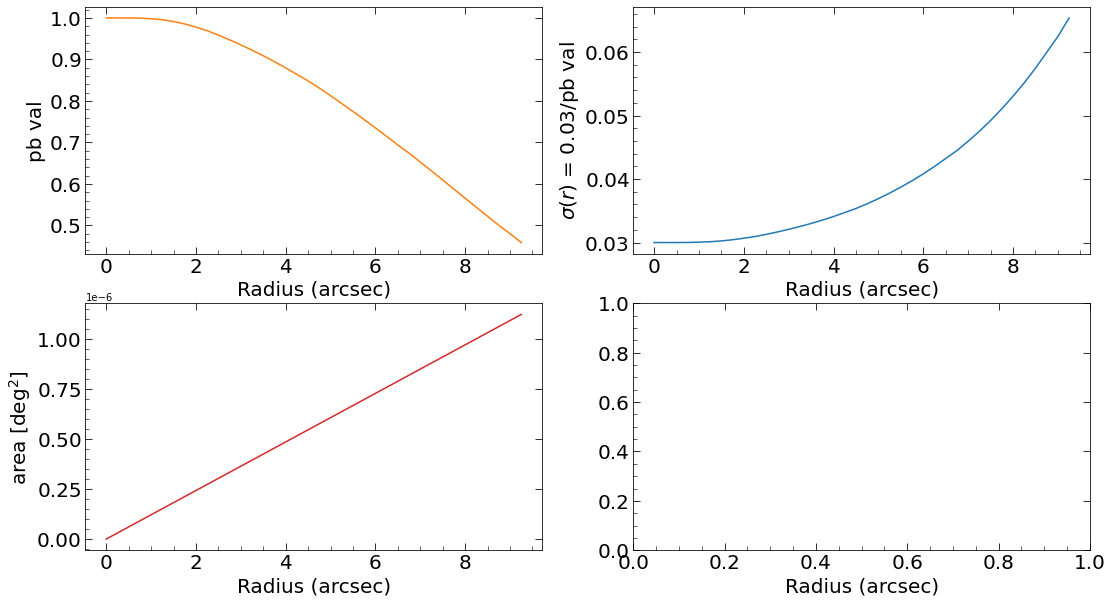

In [5]:
fig, ax = plot_galaxy_contamination_models(df)

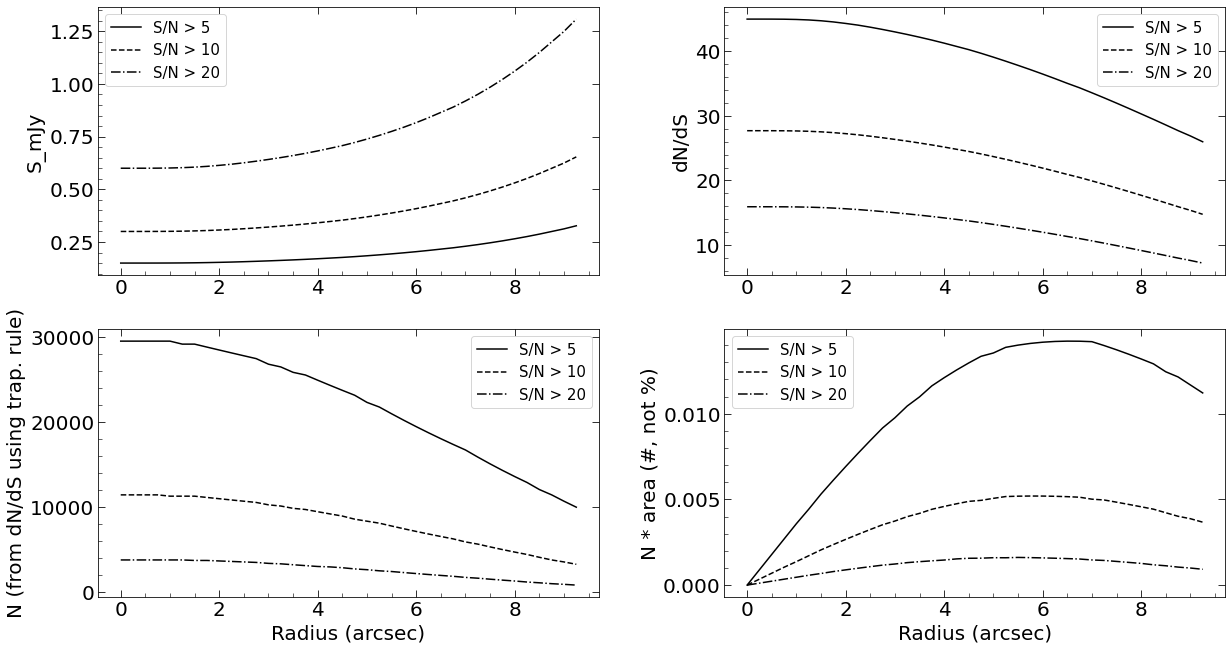

In [6]:
fig, ax = plot_probability_models(dfs, sn_array)

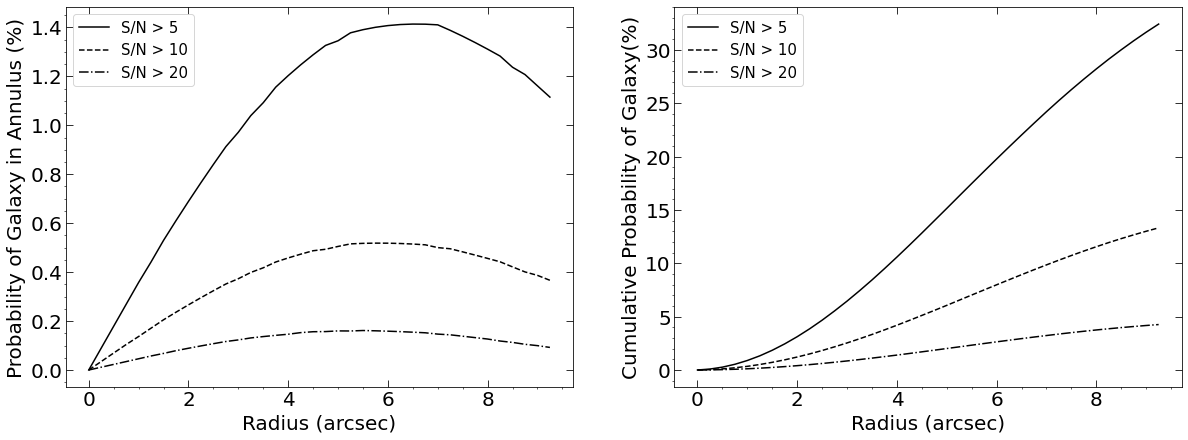

In [7]:
fig, ax = recreate_figs_11_12_sadavoy2019(dfs, sn_array)

## Find probability

In [37]:
# def galaxy_contamination_probability():
#     if band = Band 
    

In [38]:
S_source_mJy = 4.008985706605e-4 * 1000

err = constants.StokesI_err_mJy_band7
S_N_source = S_source / err

print(rf'The max StokesI of the source is: {S_source_mJy:.3f}')
print(rf'From CARTA this occurs at (472, 773)')
print(rf'Check that StokesI_mJy[472, 773]: {StokesI_mJy[472, 773]:.3f}')

print(" ")

print(rf"At Band 7 Stokes I has a constant error of: {err}")
print(rf"Stokes I of source / err: {S_N_source:.3f}")

The max StokesI of the source is: 0.401
From CARTA this occurs at (472, 773)
Check that StokesI_mJy[472, 773]: 0.401
 
At Band 7 Stokes I has a constant error of: 0.035175
Stokes I of source / err: 11.397


In [39]:
x_dist = 4.752000
y_dist = 0.684000
hypot_dist = 4.800975

print(rf'Check: {np.sqrt(x_dist**2 + y_dist**2):.6f}')

Check: 4.800975


In [40]:
print(rf"The distance to the source is in x is: {x_dist} arcsec")

closest_r = df["r_arcsec"].iloc[(df["r_arcsec"] - x_dist).abs().argmin()]
closest_idx = (df["r_arcsec"] - x_dist).abs().argmin()

print(rf"The closest r is: {closest_r } arcsec")


print(" ")
print(" ")

for i in range(len(sn_array)):

    print(rf"If the source S/N > {sn_array[i]}:")
    print(rf"     The cumulative prob is: {dfs[i]['prob_cumulative'][closest_idx]:.2f}%")
    print(" ")

The distance to the source is in x is: 4.752 arcsec
The closest r is: 4.75 arcsec
 
 
If the source S/N > 5:
     The cumulative prob is: 14.00%
 
If the source S/N > 10:
     The cumulative prob is: 5.59%
 
If the source S/N > 20:
     The cumulative prob is: 1.86%
 
